In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-17T13:49:33.745905+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

scipy     : 1.14.1
requests  : 2.34.2
marimo    : 0.23.2
seaborn   : 0.13.2
teeplot   : 1.4.2
numpy     : 2.1.2
matplotlib: 3.10.7
pandas    : 2.2.3

```

## Data

Load the per-replicate Hamming-weight end-state table produced by
the 3-site mutation-rate sweep slurm job
(`slurm/2026-06-17/2026-06-17-3site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`), cached as a parquet on
OSF. The sweep fixes `N_SITES=3` and steps `MUTATION_RATE` across a
geometric grid of 17 conditions spanning `1e-9` to `1e-1` (~2 points
per decade) at 200 replicates each, 5000 steps per replicate,
POP_SIZE=1_000_000, on CPU (engine=numpy). The dataframe has one row
per `(replicate_uid, hw)` at the final simulation step recording the
per-Hamming-weight number of cases (`n_cases`), alongside the
simulation parameters --- notably the swept `mutation_rate` --- as
constant-valued columns.

The OSF slug is downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copy.

In [ ]:
# CLI args. Defaults pull the 3-site mutation-sweep hw parquet that
# backs this notebook (OSF https://osf.io/8eqw3).
_args = mo.cli_args()
OSF_SLUG = str(_args.get("osf-slug") or "8eqw3")
OSF_URL = str(
    _args.get("osf-url") or f"https://osf.io/{OSF_SLUG}/download",
)
print(f"args: OSF_SLUG={OSF_SLUG} OSF_URL={OSF_URL}")

args: OSF_SLUG=8eqw3 OSF_URL=https://osf.io/8eqw3/download


In [ ]:
cache_path = pathlib.Path("/tmp") / OSF_SLUG
if not cache_path.exists():
    print(f"downloading {OSF_URL} -> {cache_path}")
    resp = requests.get(OSF_URL, allow_redirects=True, timeout=120)
    resp.raise_for_status()
    cache_path.write_bytes(resp.content)
else:
    print(f"reusing cached {cache_path}")
print(f"size: {cache_path.stat().st_size} bytes")

hw_df = pd.read_parquet(cache_path)
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts:\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/8eqw3/download -> /tmp/8eqw3
size: 270399 bytes
loaded hw dataframe: (13528, 20)
mutation_rate x replicate counts:
mutation_rate
1.000000e-09    200
3.000000e-09    199
1.000000e-08    194
3.000000e-08    200
1.000000e-07    196
               ... 
1.000000e-03    200
3.000000e-03    200
1.000000e-02    198
3.000000e-02    200
1.000000e-01    200
Name: replicate_uid, Length: 17, dtype: int64


## Fixation Outcome per Replicate

For each replicate, take its **last simulation step** and identify
the **dominant Hamming-weight class** by case count (`n_cases`) ---
the Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used in
the founder-convergence analyses.

With `N_SITES=3` there are four Hamming-weight classes drawn from
the eight possible genomes:

- **founder strain (000/111)**: Hamming weights `0` and `3`, i.e.
  the all-zero founder/wildtype genome and its bitwise complement
  (`hw in {0, 3}`, 2 of the 8 genomes).
- **HW 1/2 complements**: Hamming weights `1` and `2`, the
  intermediate one- and two-mutation classes that are bitwise
  complements of one another (`hw in {1, 2}`, 6 of the 8 genomes).

We classify each replicate's end-state into one of these two
categories, then ask how the **probability of the founder strain
fixing** (vs. the HW 1/2 complements fixing) depends on the swept
`mutation_rate`.

In [ ]:
# Restrict to each replicate's final step (n_steps is constant within
# a replicate, but compute per-replicate to be safe).
_last_steps = hw_df.groupby("replicate_uid")["Step"].transform("max")
_last = hw_df[hw_df["Step"] == _last_steps]

# Dominant (most-populous) Hamming-weight class per replicate at the
# final step. idxmax breaks ties toward the lower hw, which is fine
# for a coarse fixed-strain label.
_dom_idx = _last.groupby("replicate_uid")["n_cases"].idxmax()
outcome_df = _last.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "hw"],
].copy()

# Founder strain (000/111) == extreme Hamming weights {0, N_SITES};
# HW 1/2 complements == the intermediate weights {1, 2}.
outcome_df["group"] = outcome_df["hw"].map(
    lambda _hw: "founder (000/111)"
    if _hw in (0, 3)
    else "HW 1/2 complements",
)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (3382, 4)
dominant hw class counts:
hw
0     475
1    1211
2    1238
3     458
Name: count, dtype: int64
group counts:
group
HW 1/2 complements    2449
founder (000/111)      933
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

For each `mutation_rate` the fixation outcome is a Bernoulli trial
per replicate (founder strain fixes or not), so the per-condition
fraction of replicates is a **binomial proportion**. We summarize it
with the **exact Clopper-Pearson interval** via
`scipy.stats.binomtest(k, n).proportion_ci(method="exact")` --- an
exact estimator CI inverted from the binomial CDF, **not** a
bootstrap. The complementary "HW 1/2 complements" series uses the
same exact construction on the `n - k` complementary successes, so
its interval is the exact CI for that proportion (and is not merely a
reflection of the founder interval).

In [ ]:
_groups = ["founder (000/111)", "HW 1/2 complements"]
_rows = []
for _mr, _sub in outcome_df.groupby("mutation_rate"):
    _n = len(_sub)
    _k_founder = int((_sub["group"] == "founder (000/111)").sum())
    _k_by_group = {
        "founder (000/111)": _k_founder,
        "HW 1/2 complements": _n - _k_founder,
    }
    for _group in _groups:
        _k = _k_by_group[_group]
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "group": _group,
                "n_fixed": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(
        ["group", "mutation_rate"],
    )
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate              group  n_fixed  n_total        p   ci_low  ci_high
  1.000000e-09 HW 1/2 complements      125      200 0.625000 0.553949 0.692286
  3.000000e-09 HW 1/2 complements      163      199 0.819095 0.758457 0.869963
  1.000000e-08 HW 1/2 complements      171      194 0.881443 0.827433 0.923341
  3.000000e-08 HW 1/2 complements      187      200 0.935000 0.891413 0.964939
  1.000000e-07 HW 1/2 complements      192      196 0.979592 0.948574 0.994412
  3.000000e-07 HW 1/2 complements      196      200 0.980000 0.949586 0.994524
  1.000000e-06 HW 1/2 complements      188      200 0.940000 0.897538 0.968616
  3.000000e-06 HW 1/2 complements      174      195 0.892308 0.840100 0.932089
  1.000000e-05 HW 1/2 complements       38      200 0.190000 0.138103 0.251332
  3.000000e-05 HW 1/2 complements        3      200 0.015000 0.003104 0.043208
  1.000000e-04 HW 1/2 complements        2      200 0.010000 0.001213 0.035655
  3.000000e-04 HW 1/2 complements       12      200 

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition fixation probability against
`mutation_rate` on a **log x-axis**, one line per outcome group. The
shaded **band shows the exact (Clopper-Pearson) 95% confidence
interval** computed above (seaborn's own bootstrap CI is disabled
via `errorbar=None`; the band is drawn from the exact estimator).
The dashed **horizontal rule at 25%** marks the chance expectation
that one of the two founder-aligned genomes (000/111, 2 of the 8
possible 3-site genomes) fixes under a uniform-over-genomes null.

teeplots/2026-06-17-3site-mutation-sweep/a=founder-vs-hw12-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-06-17-3site-mutation-sweep/a=founder-vs-hw12-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.png


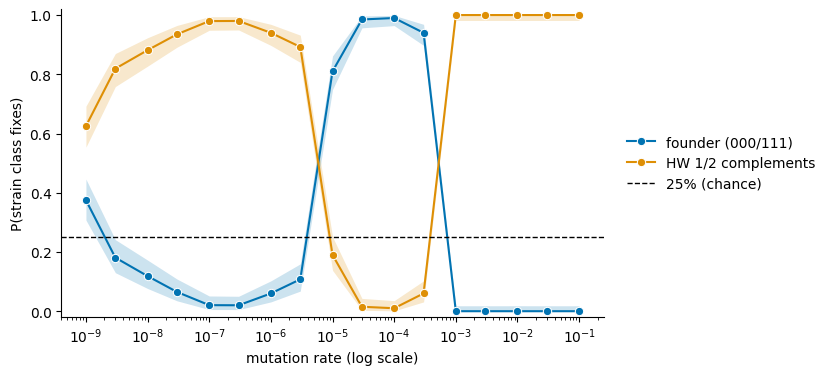

In [ ]:
_groups = ["founder (000/111)", "HW 1/2 complements"]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={"a": "founder-vs-hw12-fixation-prob"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per group (fill_between, not bootstrap).
    for _group in _groups:
        _sub = summary_df[summary_df["group"] == _group].sort_values(
            "mutation_rate",
        )
        _ax.fill_between(
            _sub["mutation_rate"],
            _sub["ci_low"],
            _sub["ci_high"],
            color=_palette[_group],
            alpha=0.2,
            linewidth=0,
        )
    # Chance expectation for the founder pair (2 of 8 genomes).
    _ax.axhline(
        0.25,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="25% (chance)",
    )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`mutation_rate` fixation probability with the exact
Clopper-Pearson 95% confidence interval, for both outcome groups.
`n_fixed` / `n_total` are the binomial counts behind each estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "mutation_rate",
            "n_fixed",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

             group  mutation_rate  n_fixed  n_total      p  ci_low  ci_high          ci_95
HW 1/2 complements   1.000000e-09      125      200 0.6250  0.5539   0.6923 [0.554, 0.692]
HW 1/2 complements   3.000000e-09      163      199 0.8191  0.7585   0.8700 [0.758, 0.870]
HW 1/2 complements   1.000000e-08      171      194 0.8814  0.8274   0.9233 [0.827, 0.923]
HW 1/2 complements   3.000000e-08      187      200 0.9350  0.8914   0.9649 [0.891, 0.965]
HW 1/2 complements   1.000000e-07      192      196 0.9796  0.9486   0.9944 [0.949, 0.994]
HW 1/2 complements   3.000000e-07      196      200 0.9800  0.9496   0.9945 [0.950, 0.995]
HW 1/2 complements   1.000000e-06      188      200 0.9400  0.8975   0.9686 [0.898, 0.969]
HW 1/2 complements   3.000000e-06      174      195 0.8923  0.8401   0.9321 [0.840, 0.932]
HW 1/2 complements   1.000000e-05       38      200 0.1900  0.1381   0.2513 [0.138, 0.251]
HW 1/2 complements   3.000000e-05        3      200 0.0150  0.0031   0.0432 [0.003, 0.043]

,group,mutation_rate,n_fixed,n_total,p,ci_low,ci_high,ci_95
0,HW 1/2 complements,1.000000e-09,125,200,0.6250,0.5539,0.6923,"[0.554, 0.692]"
1,HW 1/2 complements,3.000000e-09,163,199,0.8191,0.7585,0.8700,"[0.758, 0.870]"
2,HW 1/2 complements,1.000000e-08,171,194,0.8814,0.8274,0.9233,"[0.827, 0.923]"
3,HW 1/2 complements,3.000000e-08,187,200,0.9350,0.8914,0.9649,"[0.891, 0.965]"
4,HW 1/2 complements,1.000000e-07,192,196,0.9796,0.9486,0.9944,"[0.949, 0.994]"
...,...,...,...,...,...,...,...,...
29,founder (000/111),1.000000e-03,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
30,founder (000/111),3.000000e-03,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
31,founder (000/111),1.000000e-02,0,198,0.0000,0.0000,0.0185,"[0.000, 0.018]"
32,founder (000/111),3.000000e-02,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
